In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../data/raw/Telco_Customer_Churn_Dataset .csv")

data.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [3]:
data.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
(data["TotalCharges"] == " ").sum()

np.int64(0)

In [12]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"] , errors = "coerce") 

In [13]:
data['TotalCharges'].dtype

dtype('float64')

In [14]:
data["TotalCharges"].isnull().sum()

np.int64(11)

In [15]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

data["TotalCharges"].isnull().sum()

np.int64(0)

In [16]:
data.drop('customerID' , axis = 1, inplace=True)

In [17]:
data_encoded = pd.get_dummies(data , drop_first = True)

print(data_encoded.shape)

(7043, 31)


In [18]:
data["TotalCharges"].isnull().sum()
print(data_encoded.shape)

(7043, 31)


In [19]:
data.to_csv('../data/cleaned/cleaned_Telco_Customer_Churn_Dataset.csv')

###  Overall Churn Rate

In [20]:
churn_rate = data["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


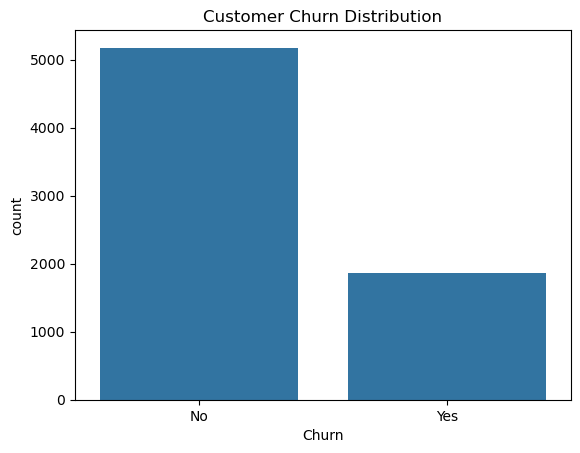

In [21]:

sns.countplot(x="Churn", data=data)
plt.title("Customer Churn Distribution")
plt.show()

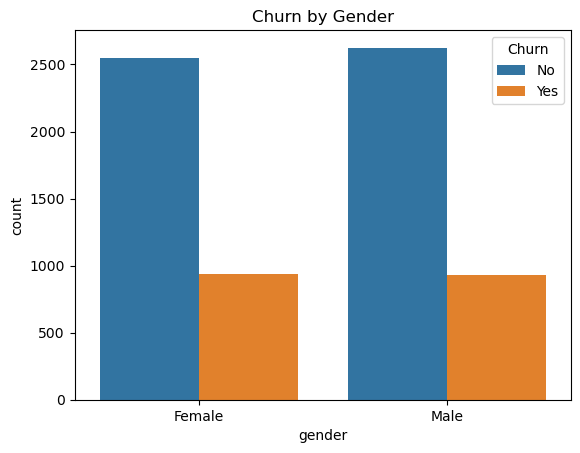

In [22]:
sns.countplot(x="gender", hue="Churn", data=data)
plt.title("Churn by Gender")
plt.show()

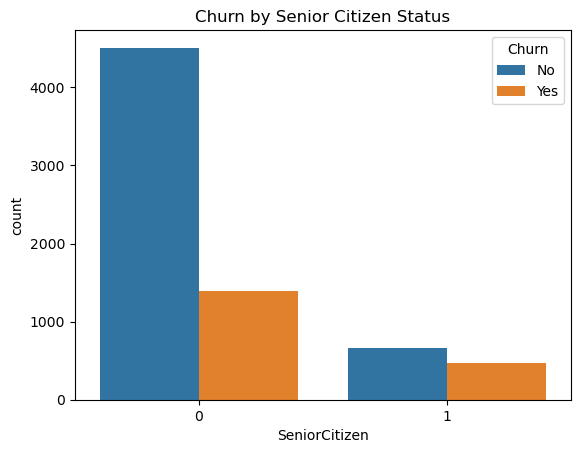

In [23]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=data)
plt.title("Churn by Senior Citizen Status")
plt.show()

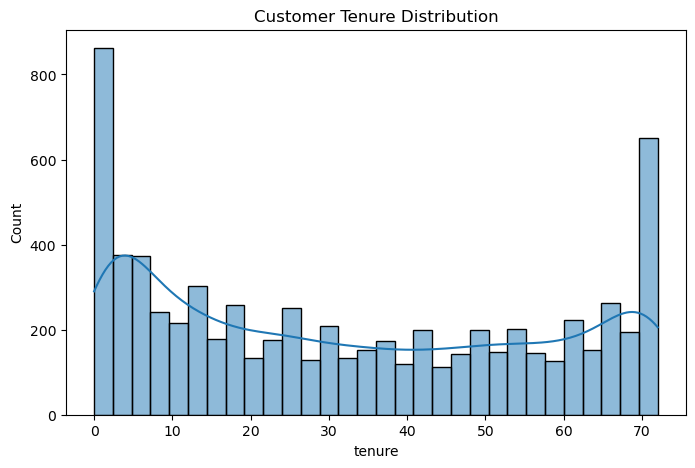

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data["tenure"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

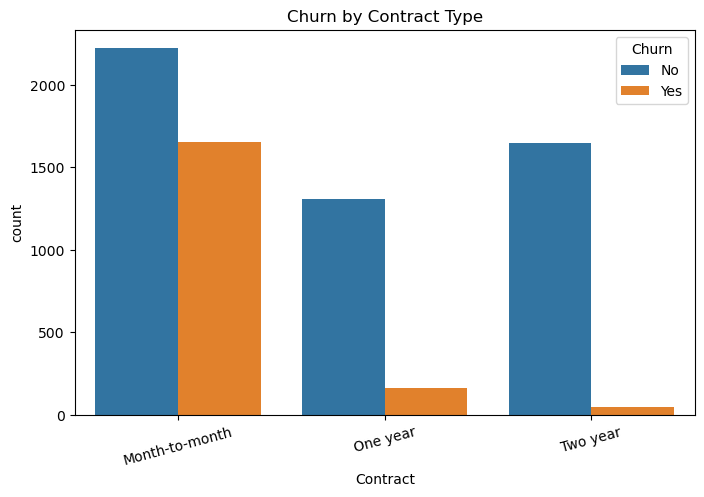

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

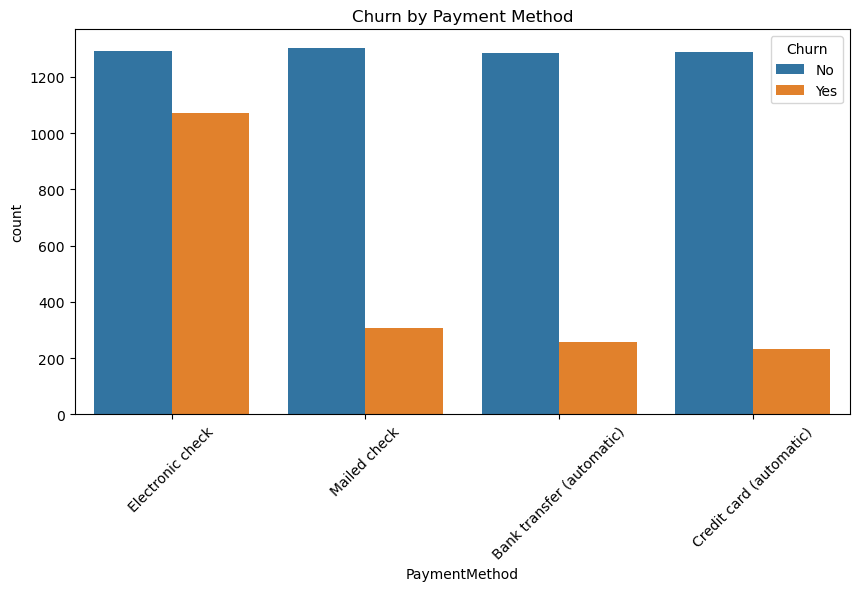

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=data)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

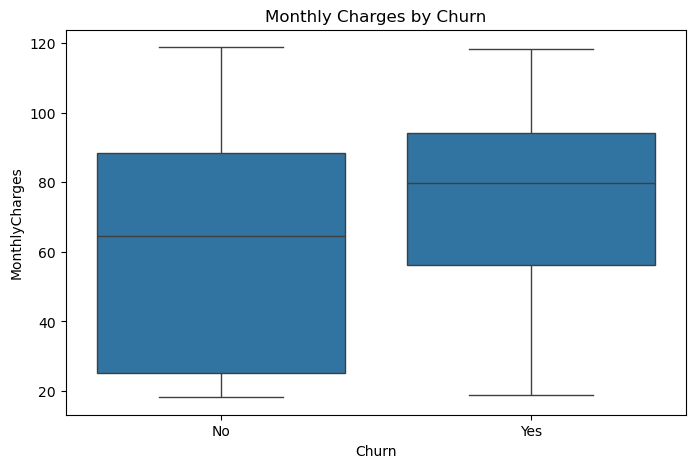

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)
plt.title("Monthly Charges by Churn")
plt.show()

# Task 3: Customer Segmentation

In [28]:
data["TenureGroup"] = pd.cut(
    data["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-12","13-24","25-48","49-72"]
)

In [29]:
tenure_churn = pd.crosstab(
    data["TenureGroup"],
    data["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn               No        Yes
TenureGroup                      
0-12         52.321839  47.678161
13-24        71.289062  28.710938
25-48        79.611041  20.388959
49-72        90.486824   9.513176


In [30]:
data["ChargeGroup"] = pd.qcut(
    data["MonthlyCharges"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

In [31]:
charge_churn = pd.crosstab(
    data["ChargeGroup"],
    data["Churn"],
    normalize="index"
) * 100

print(charge_churn)

Churn               No        Yes
ChargeGroup                      
Low          88.762770  11.237230
Medium       75.424689  24.575311
High         62.492886  37.507114
Very High    67.121729  32.878271


In [32]:
contract_churn = pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


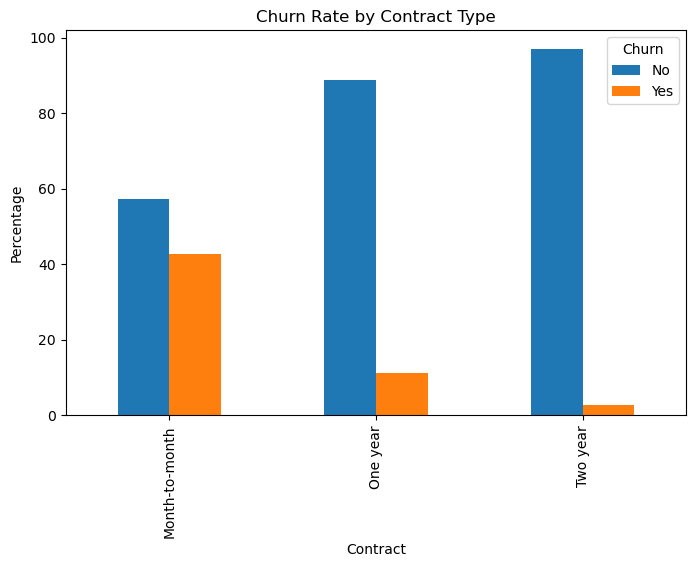

In [33]:
contract_churn.plot(kind="bar", figsize=(8,5))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.show()

## Day 4: Churn Prediction Model

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [35]:
df_model = data.copy()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))

for col in df_model.select_dtypes(include=['category']).columns:
    df_model[col] = df_model[col].cat.codes

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5634, 21)
Testing Shape: (1409, 21)


In [36]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("\nModel trained successfully!")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")


Model trained successfully!

Accuracy: 81.41%


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 81.41 %

Confusion Matrix:
[[932 104]
 [158 215]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.67      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



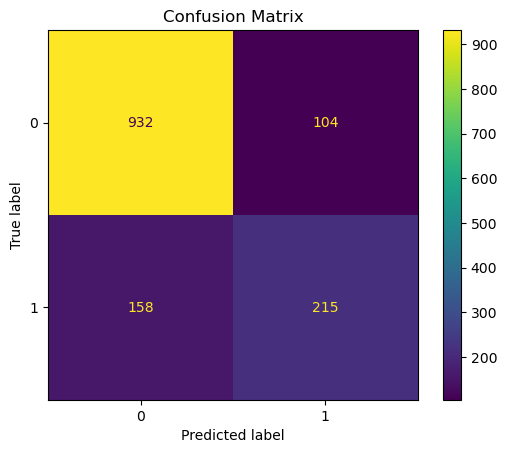

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()